# Phân tích dự đoán

## 1. Phân cụm Khách hàng
**Mục tiêu**: Tự động gom nhóm khách hàng có hành vi tương đồng mà không cần định nghĩa trước. Rút insight từ các nhóm khách hàng

`notebooks/05a_clustering.ipynb`

## 2. Dự báo Sự rời bỏ
**Mục tiêu**: Dự đoán khách đang hoạt động có thể rời bỏ sàn trong 150 ngày tới không?

### 2.1 Xây dựng file train, test

#### 2.1.1 Load data

In [40]:
# Import library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
# from sklearn.metrics import plot_confusion_matrix
import category_encoders as ce
from imblearn.over_sampling import SMOTE, SVMSMOTE

In [51]:
customers = pd.read_csv("../data/2_clean/customers.csv")
orders = pd.read_csv("../data/2_clean/orders.csv")
order_items = pd.read_csv("../data/2_clean/order_items.csv")
payments = pd.read_csv("../data/2_clean/payments.csv")
products = pd.read_csv("../data/2_clean/products.csv")
reviews = pd.read_csv("../data/2_clean/reviews.csv")

clustered_df = pd.read_csv("../data/3_model/clustered_data.csv")

#### 2.1.2 Chọn lọc nhóm đối tượng
**Lý do**: Không xét nhóm đối tượng một thời gian dài chưa mua, không mua thường xuyên và tổng chi còn thấp(Re-Engage).

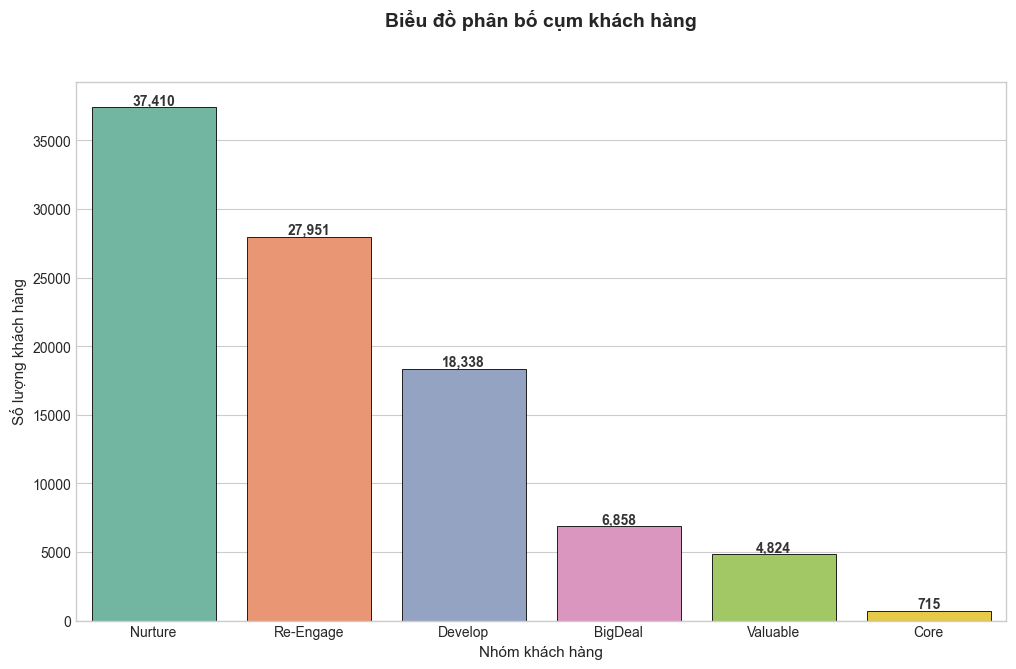

In [44]:
cluster_count = clustered_df["ClusterLabel"].value_counts()
feature_means = clustered_df.groupby("ClusterLabel")[["monetary", "frequency", "recency"]].mean()


fig, ax1 = plt.subplots(figsize=(12, 7))

# =========================
# Bar chart: số lượng khách hàng
# =========================
sns.barplot(
    x=cluster_count.index,
    y=cluster_count.values,
    hue=cluster_count.index,
    palette="Set2",
    legend=False,
    edgecolor="black",
    linewidth=0.6,
    ax=ax1
)

ax1.set_xlabel("Nhóm khách hàng", fontsize=11)
ax1.set_ylabel("Số lượng khách hàng", fontsize=11)

ax1.set_title(
    "Biểu đồ phân bố cụm khách hàng",
    fontsize=14,
    fontweight="bold",
    pad=40
)

# Ghi số lên đầu cột
for i, v in enumerate(cluster_count.values):
    ax1.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

In [52]:
df = clustered_df[(clustered_df["ClusterLabel"] != "Nurture") & (clustered_df["ClusterLabel"] != "Re-Engage") & (clustered_df["frequency"] != 0)]

In [53]:
df

,customer_unique_id,recency,frequency,monetary,Cluster,ClusterLabel
0,f2f42cdcf50f93b06b166895a3919f26,444,1,357.08,2,Develop
1,8aa01aca756c6533618555d7195513fe,266,1,357.03,2,Develop
2,cdf582422b69d4fbf906a9bb532089ce,406,1,357.03,2,Develop
3,ac73a055ee14753b14b49a26db9dc7d9,406,1,357.03,2,Develop
4,7a499f0679383d730d17aeb697b7addb,412,1,357.03,2,Develop
...,...,...,...,...,...,...
96091,d7bf7cfe09c3d0f40e1cabde2dc17fd4,111,2,358.49,-3,Core
96092,bf087cbc0138d7066e1c41d1a97973dd,111,2,358.44,-3,Core
96093,f170c6e04c4cdf9219fc5c669b10f506,277,2,357.96,-3,Core
96094,2e08911037fe7ec67377711eee1fdbf3,230,2,357.78,-3,Core


In [54]:
customers = customers[customers["customer_unique_id"].isin(df["customer_unique_id"])]


In [55]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_name,region
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,São Paulo,Southeast
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,São Paulo,Southeast
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,São Paulo,Southeast
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC,Santa Catarina,South
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,Paraná,South
...,...,...,...,...,...,...,...
99414,eabf770240659f7a6d09b11f12f10f89,065b9e6198f11dbdf7fc1250f9e08afc,19905,ourinhos,SP,São Paulo,Southeast
99415,184e0c2cfc746789643521df0e9ff904,c64ede6d0ae8901b1b6fb03528c1b7e6,68660,sao miguel do guama,PA,Pará,North
99417,b7c889215de76857c7967c1011125d2d,522e244a96d13876c5bac4985a8d5075,82410,curitiba,PR,Paraná,South
99429,1ed0c832c2dd99570a59260e71768bdf,82d46759af0369aad49084bacf85a6c3,37610,bom repouso,MG,Minas Gerais,Southeast


#### 2.1.3 Chia tập orders train/test
**Lý do**: Phục vụ cho việc xây mô hình dự đoán.

##### Xem thời gian bắt đầu và thời gian kết thúc

In [56]:
# Chuyển cột ngày tháng sang dạng datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# 3. Sắp xếp dữ liệu theo thứ tự thời gian tăng dần
orders = orders.sort_values(by='order_purchase_timestamp')

# Kiểm tra khoảng thời gian của dữ liệu
print(f"Ngày bắt đầu: {orders['order_purchase_timestamp'].min()}")
print(f"Ngày kết thúc: {orders['order_purchase_timestamp'].max()}")

Ngày bắt đầu: 2016-09-04 21:15:19
Ngày kết thúc: 2018-10-17 17:30:18


##### Chọn 80 train, 20 test
Tổng 25 tháng => Lấy mốc `01/06/2018` (6 tháng)

In [59]:
def split_orders(orders, input_date):
    # Chọn ngày cắt
    split_date = pd.Timestamp(input_date)

    # Tạo mask lọc
    train_mask = orders['order_purchase_timestamp'] < split_date
    test_mask = orders['order_purchase_timestamp'] >= split_date

    # Chia dữ liệu
    orders_train_df = orders.loc[train_mask]
    orders_test_df = orders.loc[test_mask]

    # Kiểm tra tỷ lệ
    n_total = len(orders)
    n_train = len(orders_train_df)
    n_test = len(orders_test_df)

    print(f"Số lượng dòng Train: {n_train} ({n_train/n_total:.1%})")
    print(f"Số lượng dòng Test: {n_test} ({n_test/n_total:.1%})")

    return orders_train_df, orders_test_df

orders_train_df, orders_test_df = split_orders(orders, '2018-06-01')

Số lượng dòng Train: 80450 (80.9%)
Số lượng dòng Test: 18991 (19.1%)


#### 2.1.4 Featuring data cho tập train/test + Đánh label churn (mốc 140 ngày)

In [ ]:
def safe_qcut(s, q, labels):
    s = s.fillna(-1)
    r = s.rank(method="first")
    try:
        return pd.qcut(r, q=q, labels=labels)
    except ValueError:
        return pd.cut(r, bins=q, labels=labels)

def build_customer_features(customers, orders, payments, reviews, snapshot_date):
    snapshot_date = pd.to_datetime(snapshot_date)

    orders = orders[
        pd.to_datetime(orders["order_purchase_timestamp"]) <= snapshot_date
    ].copy()

    df = orders.merge(
        customers[["customer_id", "customer_unique_id", "customer_state"]],
        on="customer_id",
        how="left"
    )

    pay = payments.groupby("order_id", as_index=False)["payment_value"].sum()
    df = df.merge(pay, on="order_id", how="left").fillna({"payment_value": 0})

    agg = df.groupby("customer_unique_id").agg(
        total_orders=("order_id", "nunique"),
        monetary=("payment_value", "sum"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max"),
        customer_state=("customer_state", "first")
    ).reset_index()

    delivered = df[df["order_status"] == "delivered"].copy()
    delivered["delivery_days"] = (
        pd.to_datetime(delivered["order_delivered_customer_date"]) -
        pd.to_datetime(delivered["order_purchase_timestamp"])
    ).dt.days

    delivered["late"] = (
        pd.to_datetime(delivered["order_delivered_customer_date"]) >
        pd.to_datetime(delivered["order_estimated_delivery_date"])
    ).astype(int)

    deliv = delivered.groupby("customer_unique_id").agg(
        delivered_orders=("order_id", "nunique"),
        num_late_deliveries=("late", "sum"),
        avg_delivery_days=("delivery_days", "mean")
    ).reset_index()

    agg = agg.merge(deliv, on="customer_unique_id", how="left").fillna(0)

    agg["recency_days"] = (snapshot_date - pd.to_datetime(agg["last_purchase"])).dt.days
    agg["customer_age_days"] = (snapshot_date - pd.to_datetime(agg["first_purchase"])).dt.days

    agg["avg_order_value"] = agg["monetary"] / agg["delivered_orders"].replace(0, 1)
    agg["orders_per_month"] = agg["total_orders"] / (agg["customer_age_days"] / 30).replace(0, 1)

    rev = reviews.groupby("order_id", as_index=False)["review_score"].mean()
    rev = orders.merge(rev, on="order_id", how="left")

    rev_agg = rev.merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id"
    ).groupby("customer_unique_id", as_index=False)["review_score"].mean()

    agg = agg.merge(rev_agg, on="customer_unique_id", how="left").fillna({"review_score": 0})

    agg["r_score"] = safe_qcut(agg["recency_days"], 5, [5,4,3,2,1]).astype(int)
    agg["f_score"] = safe_qcut(agg["delivered_orders"], 5, [1,2,3,4,5]).astype(int)
    agg["m_score"] = safe_qcut(agg["monetary"], 5, [1,2,3,4,5]).astype(int)

    return agg[
        [
            "customer_unique_id",
            "recency_days", "delivered_orders", "monetary",
            "r_score", "f_score", "m_score",
            "total_orders", "orders_per_month", "avg_order_value",
            "num_late_deliveries", "avg_delivery_days",
            "review_score", "customer_state"
        ]
    ]

def create_label(customers, orders, start_date, end_date):
    orders = orders[
        (pd.to_datetime(orders["order_purchase_timestamp"]) >= start_date) &
        (pd.to_datetime(orders["order_purchase_timestamp"]) <= end_date)
    ]

    repurchased_ids = orders["customer_id"].unique()

    return (
        customers[["customer_id", "customer_unique_id"]]
        .assign(is_repurchase=lambda x: x["customer_id"].isin(repurchased_ids).astype(int))
        [["customer_unique_id", "is_repurchase"]]
    )

def build_features(customers, orders, payments, reviews, snapshot_date):
    return build_customer_features(
        customers, orders, payments, reviews, snapshot_date
    )

In [ ]:
SNAPSHOT_DATE = "2018-06-01"
LABEL_END_DATE = "2018-10-18"  # 140 ngày

X_train = build_features(
    customers=customers,
    orders=orders,
    payments=payments,
    reviews=reviews,
    snapshot_date=SNAPSHOT_DATE
)

y_train = create_label(
    customers=customers,
    orders=orders,
    start_date=SNAPSHOT_DATE,
    end_date=LABEL_END_DATE
)

train_df = X_train.merge(y_train, on="customer_unique_id", how="left").fillna(0)
train_df

,customer_unique_id,recency_days,delivered_orders,monetary,r_score,f_score,m_score,total_orders,orders_per_month,avg_order_value,num_late_deliveries,avg_delivery_days,review_score,customer_state,is_repurchase
0,0004aac84e0df4da2b147fca70cf8255,198,1.0,196.89,2,1,2,1,0.151515,196.89,0.0,13.0,5.0,SP,0
1,0004bd2a26a76fe21f786e4fbd80607f,56,1.0,166.98,5,1,1,1,0.535714,166.98,0.0,1.0,4.0,SP,0
2,00053a61a98854899e70ed204dd4bafe,92,1.0,419.18,4,1,5,1,0.326087,419.18,0.0,16.0,1.0,PR,0
3,000de6019bb59f34c099a907c151d855,287,1.0,257.44,1,1,3,1,0.104530,257.44,0.0,4.0,2.0,SP,0
4,0010a452c6d13139e50b57f19f52e04e,324,1.0,325.93,1,1,4,1,0.092593,325.93,0.0,14.0,1.0,RS,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26072,fff1bdd5c5e37ca79dd74deeb91aa5b6,96,1.0,172.98,4,5,1,1,0.312500,172.98,1.0,58.0,1.0,TO,0
26073,fff2ae16b99c6f3c785f0e052f2a9cfb,41,1.0,200.90,5,5,2,1,0.731707,200.90,0.0,21.0,5.0,RJ,0
26074,fff7219c86179ca6441b8f37823ba3d3,155,1.0,265.80,3,5,3,1,0.193548,265.80,0.0,23.0,4.0,RJ,0
26075,fffbf87b7a1a6fa8b03f081c5f51a201,155,1.0,167.32,3,5,1,1,0.193548,167.32,0.0,18.0,5.0,CE,0


In [87]:
print(train_df["is_repurchase"].value_counts())

is_repurchase
0    25630
1      447
Name: count, dtype: int64


In [88]:
test_last_date = "2018-10-18"

test_df = build_features(
    customers,
    orders,
    payments,
    reviews,
    snapshot_date=test_last_date
)
test_df

,customer_unique_id,recency_days,delivered_orders,monetary,r_score,f_score,m_score,total_orders,orders_per_month,avg_order_value,num_late_deliveries,avg_delivery_days,review_score,customer_state
0,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,2,1,0.089021,196.89,0,13.0,5.0,SP
1,0004bd2a26a76fe21f786e4fbd80607f,195,1,166.98,4,1,1,1,0.153846,166.98,0,1.0,4.0,SP
2,00053a61a98854899e70ed204dd4bafe,231,1,419.18,3,1,4,1,0.129870,419.18,0,16.0,1.0,PR
3,000de6019bb59f34c099a907c151d855,426,1,257.44,1,1,3,1,0.070423,257.44,0,4.0,2.0,SP
4,000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38,5,1,4,1,0.361446,362.38,0,8.0,5.0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27992,fff2ae16b99c6f3c785f0e052f2a9cfb,180,1,200.90,4,5,2,1,0.166667,200.90,0,21.0,5.0,RJ
27993,fff5eb4918b2bf4b2da476788d42051c,107,1,2844.96,5,5,5,1,0.280374,2844.96,0,13.0,5.0,PB
27994,fff7219c86179ca6441b8f37823ba3d3,294,1,265.80,3,5,3,1,0.102041,265.80,0,23.0,4.0,RJ
27995,fffbf87b7a1a6fa8b03f081c5f51a201,294,1,167.32,3,5,1,1,0.102041,167.32,0,18.0,5.0,CE


In [89]:
train_df.to_csv("../data/3_model/train.csv", index=False)
test_df.to_csv("../data/3_model/test.csv", index=False)

### 2.4 Xây dựng mô hình

#### 2.4.1 Load data

In [105]:
train_df = pd.read_csv("../data/3_model/train.csv")

In [106]:
train_df

,customer_unique_id,recency_days,delivered_orders,monetary,r_score,f_score,m_score,total_orders,orders_per_month,avg_order_value,num_late_deliveries,avg_delivery_days,review_score,customer_state,is_repurchase
0,0004aac84e0df4da2b147fca70cf8255,198,1.0,196.89,2,1,2,1,0.151515,196.89,0.0,13.0,5.0,SP,0
1,0004bd2a26a76fe21f786e4fbd80607f,56,1.0,166.98,5,1,1,1,0.535714,166.98,0.0,1.0,4.0,SP,0
2,00053a61a98854899e70ed204dd4bafe,92,1.0,419.18,4,1,5,1,0.326087,419.18,0.0,16.0,1.0,PR,0
3,000de6019bb59f34c099a907c151d855,287,1.0,257.44,1,1,3,1,0.104530,257.44,0.0,4.0,2.0,SP,0
4,0010a452c6d13139e50b57f19f52e04e,324,1.0,325.93,1,1,4,1,0.092593,325.93,0.0,14.0,1.0,RS,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26072,fff1bdd5c5e37ca79dd74deeb91aa5b6,96,1.0,172.98,4,5,1,1,0.312500,172.98,1.0,58.0,1.0,TO,0
26073,fff2ae16b99c6f3c785f0e052f2a9cfb,41,1.0,200.90,5,5,2,1,0.731707,200.90,0.0,21.0,5.0,RJ,0
26074,fff7219c86179ca6441b8f37823ba3d3,155,1.0,265.80,3,5,3,1,0.193548,265.80,0.0,23.0,4.0,RJ,0
26075,fffbf87b7a1a6fa8b03f081c5f51a201,155,1.0,167.32,3,5,1,1,0.193548,167.32,0.0,18.0,5.0,CE,0


#### Hashing cutomer_state

In [120]:
df_input = train_df.drop(columns=["customer_unique_id"]).copy()

# Hasing các cột
he = ce.HashingEncoder(cols='customer_state')
df_hash = he.fit_transform(df_input)
df_hash = df_hash.loc[:, df_hash.var() > 0]

df_hash

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,recency_days,delivered_orders,monetary,r_score,f_score,m_score,total_orders,orders_per_month,avg_order_value,num_late_deliveries,avg_delivery_days,review_score,is_repurchase
0,0,0,1,0,0,0,0,198,1.0,196.89,2,1,2,1,0.151515,196.89,0.0,13.0,5.0,0
1,0,0,1,0,0,0,0,56,1.0,166.98,5,1,1,1,0.535714,166.98,0.0,1.0,4.0,0
2,0,0,0,0,0,0,1,92,1.0,419.18,4,1,5,1,0.326087,419.18,0.0,16.0,1.0,0
3,0,0,1,0,0,0,0,287,1.0,257.44,1,1,3,1,0.104530,257.44,0.0,4.0,2.0,0
4,0,0,1,0,0,0,0,324,1.0,325.93,1,1,4,1,0.092593,325.93,0.0,14.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26072,0,0,0,0,1,0,0,96,1.0,172.98,4,5,1,1,0.312500,172.98,1.0,58.0,1.0,0
26073,0,0,0,0,1,0,0,41,1.0,200.90,5,5,2,1,0.731707,200.90,0.0,21.0,5.0,0
26074,0,0,0,0,1,0,0,155,1.0,265.80,3,5,3,1,0.193548,265.80,0.0,23.0,4.0,0
26075,0,0,1,0,0,0,0,155,1.0,167.32,3,5,1,1,0.193548,167.32,0.0,18.0,5.0,0


#### Drop biến phụ thuộc cao vì ảnh hưởng

In [122]:
df_hash = df_hash.drop(columns=["total_orders", "avg_order_value"])

In [123]:
corr = df_hash.corr()
corr.style.background_gradient(cmap="coolwarm").format("{:.2f}")

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,recency_days,delivered_orders,monetary,r_score,f_score,m_score,orders_per_month,num_late_deliveries,avg_delivery_days,review_score,is_repurchase
col_0,1.00,-0.03,-0.21,-0.02,-0.15,-0.07,-0.07,0.01,-0.01,0.02,-0.01,-0.02,0.02,0.01,0.01,0.09,-0.00,-0.00
col_1,-0.03,1.00,-0.10,-0.01,-0.07,-0.03,-0.03,0.01,-0.02,0.02,-0.01,-0.00,0.03,-0.01,0.03,0.10,-0.01,-0.01
col_2,-0.21,-0.10,1.00,-0.07,-0.60,-0.29,-0.29,-0.03,0.03,-0.04,0.03,0.02,-0.03,0.01,-0.08,-0.24,0.06,0.02
col_3,-0.02,-0.01,-0.07,1.00,-0.05,-0.02,-0.02,-0.01,-0.01,0.02,0.01,0.00,0.02,0.01,0.02,0.05,-0.00,-0.00
col_4,-0.15,-0.07,-0.60,-0.05,1.00,-0.20,-0.20,0.02,-0.01,0.01,-0.03,-0.01,0.01,-0.02,0.06,0.13,-0.06,-0.01
col_5,-0.07,-0.03,-0.29,-0.02,-0.20,1.00,-0.10,-0.01,-0.01,0.00,0.00,-0.01,0.00,-0.00,0.02,0.05,-0.00,-0.00
col_6,-0.07,-0.03,-0.29,-0.02,-0.20,-0.10,1.00,0.01,-0.01,0.01,-0.01,-0.01,0.01,0.01,0.01,0.05,-0.01,-0.01
recency_days,0.01,0.01,-0.03,-0.01,0.02,-0.01,0.01,1.00,-0.02,0.08,-0.94,0.00,0.15,-0.28,-0.09,-0.04,0.04,-0.02
delivered_orders,-0.01,-0.02,0.03,-0.01,-0.01,-0.01,-0.01,-0.02,1.00,0.04,0.03,0.47,0.03,-0.00,0.09,-0.07,0.06,0.00
monetary,0.02,0.02,-0.04,0.02,0.01,0.00,0.01,0.08,0.04,1.00,-0.06,-0.02,0.61,0.01,0.02,0.03,-0.03,-0.07


#### SMOTE & SCALE & Logistic Regression
**Mục đích**
- SMOTE: giải quyết mất cân bằng giữa nhóm is_repurchased 
- Scale: Đưa các chỉ số về 0, 1 để tránh thiên vị

In [124]:
X = df_hash.drop(["is_repurchase"], axis=1)
y = df_hash["is_repurchase"]

# Chia ngẫu nhiên 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Upsampling = SMOTE
sm = SMOTE(k_neighbors=5)
X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)  

# Scale 
scale_cols = ['recency_days', 'delivered_orders', "monetary", 'r_score', 'f_score', 'm_score', 'orders_per_month', 'num_late_deliveries',
              'avg_delivery_days' , 'review_score' ]

scaler = MinMaxScaler()
scaler.fit(X_train_resample[scale_cols])
X_train_resample[scale_cols] = scaler.transform(X_train_resample[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      5131
           1       0.05      0.39      0.09        85

    accuracy                           0.87      5216
   macro avg       0.52      0.64      0.51      5216
weighted avg       0.97      0.87      0.92      5216



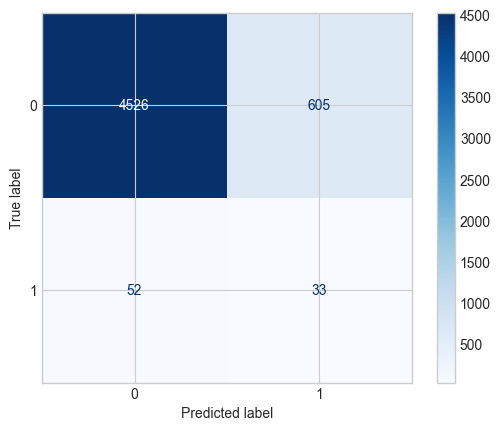

In [ ]:
# Logistic Regression
model_log = LogisticRegression() 
model_log.fit(X_train_resample, y_train_resample)
y_pred = model_log.predict(X_test)

# In dữ liệu
print(classification_report( y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model_log,
    X_test,
    y_test,
    cmap="Blues"
)

#### XGBOOST

In [135]:
# SMOTE & Scale
X = df_hash.drop(["is_repurchase"], axis=1)
y = df_hash["is_repurchase"]

# Chia train ,test
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state=42)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5131
           1       0.10      0.08      0.09        85

    accuracy                           0.97      5216
   macro avg       0.54      0.53      0.54      5216
weighted avg       0.97      0.97      0.97      5216



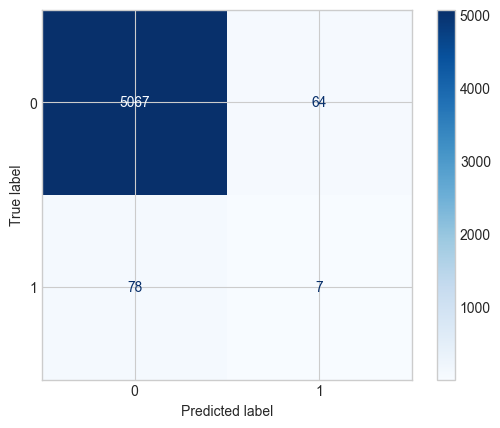

In [136]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(random_state=42, n_estimators = 200)
model_xgb.fit(X_train, y_train)


y_pred = model_xgb.predict(X_test)
# In bao cao ket qua
print(classification_report( y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    X_test,
    y_test,
    cmap="Blues"
)

In [179]:
test_df = pd.read_csv("../data/3_model/test.csv")
ids = test_df['customer_unique_id']
test_df = test_df.drop(columns=["customer_unique_id"])

# Hasing các cột
he = ce.HashingEncoder(cols='customer_state')
test_df = he.fit_transform(test_df)
test_df = test_df.loc[:, test_df.var() > 0]

test_df = test_df.drop(columns=["total_orders", "avg_order_value"])


# Scale 
test_df[scale_cols] = scaler.transform(test_df[scale_cols])

# y_pred = model_xgb.predict(test_df)
y_pred = model_log.predict(test_df)

y_pred
result_df = pd.DataFrame({'customer_unique_id':ids, 'is_repurchased':y_pred})

In [180]:
result_df

,customer_unique_id,is_repurchased
0,0004aac84e0df4da2b147fca70cf8255,0
1,0004bd2a26a76fe21f786e4fbd80607f,1
2,00053a61a98854899e70ed204dd4bafe,0
3,000de6019bb59f34c099a907c151d855,0
4,000fbf0473c10fc1ab6f8d2d286ce20c,0
...,...,...
27992,fff2ae16b99c6f3c785f0e052f2a9cfb,0
27993,fff5eb4918b2bf4b2da476788d42051c,0
27994,fff7219c86179ca6441b8f37823ba3d3,0
27995,fffbf87b7a1a6fa8b03f081c5f51a201,0


In [181]:
result_df['is_repurchased'].value_counts()

is_repurchased
0    26331
1     1666
Name: count, dtype: int64